# Automotive Part Image-Text Matching

## Final exam project

This notebook presents one controlled experiment: I use text, images, or both inputs to classify whether an automotive-part image matches a description.

The original selected model and its saved results remain unchanged. The notebook reads saved validation and final-test artifacts and does not rerun the final test.

## 1. Problem statement

The task is to classify an image-text pair as `MATCH`, `PARTIAL_MATCH`, or `MISMATCH`.

**Research question:** Can a compact multimodal model learn this three-way relation, and what do single-input checks show about the need to compare both inputs?

This can be useful for checking online product listings, catalogues, and warehouse descriptions.

### What I expect

Before comparing the results, I expect:

- the multimodal model to learn the relation because it receives both required inputs;
- image-only and text-only checks to stay near chance because each single side is balanced across the three relation labels;
- `PARTIAL_MATCH` to be difficult because the two parts are related but not identical;
- some automotive-part categories to be easier than others.

Later I also include a validation-only diagnostic and one small experiment without the two helper category tasks.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

from src.data import PROJECT_ROOT, load_image_manifest, validate_development_dataset
from src.models import (
    ImageRelationCNN,
    MultimodalRelationCNN,
    MultimodalRelationCNNNoAuxiliary,
    TextRelationMLP,
    count_trainable_parameters,
)

RESULTS = PROJECT_ROOT / "results"
manifest = load_image_manifest()
validation_comparison = pd.read_csv(RESULTS / "validation" / "model_comparison.csv")
validation_predictions = pd.read_csv(RESULTS / "validation" / "selected_model_predictions.csv")
validation_metrics = json.loads((RESULTS / "validation" / "selected_model_metrics.json").read_text())
category_rule_diagnostic = pd.read_csv(RESULTS / "validation" / "category_rule_diagnostic.csv")
category_rule_metrics = json.loads((RESULTS / "validation" / "category_rule_diagnostic.json").read_text())
text_history = pd.read_csv(RESULTS / "training" / "torch_text_dataset_v3_training_history.csv")
image_history = pd.read_csv(RESULTS / "training" / "torch_cnn_image_dataset_v3_training_history.csv")
multimodal_history = pd.read_csv(RESULTS / "training" / "torch_multimodal_dataset_v3_training_history.csv")
ablation_comparison = pd.read_csv(RESULTS / "ablation" / "auxiliary_loss_ablation_comparison.csv")
ablation_summary = json.loads((RESULTS / "ablation" / "auxiliary_loss_ablation_summary.json").read_text())
test_metrics = json.loads((RESULTS / "final_test" / "test_metrics.json").read_text())
test_predictions = pd.read_csv(RESULTS / "final_test" / "test_predictions.csv")
test_per_category = pd.read_csv(RESULTS / "final_test" / "test_per_category.csv")

print("Dataset images:", len(manifest))
print("Selected model:", validation_metrics["model_slug"])

Dataset images: 640
Selected model: torch_multimodal_dataset_v3


## 2. Data preparation and split

Dataset V3 contains eight automotive-part categories. Every image is paired with two examples of each label, giving six image-text rows per image. Exact text templates are also balanced across the labels within each development split.

I created a grouped split and checked that the same image does not appear in train, validation, and test. The checks use image IDs, groups, paths, file hashes, and exact text descriptions.

In [2]:
development_audit = validate_development_dataset(verify_hashes=False)
split_table = (
    manifest.groupby(["split", "part_category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
display(split_table)

print("Dataset check:", development_audit["status"])
print("Unique images:", development_audit["images"])
print("Unique image hashes:", development_audit["unique_hashes"])
print("Images by split:", development_audit["split_images"])
print("All overlap checks are zero:", all(value == 0 for value in development_audit["overlap"].values()))

part_category,alternator,brake_disc,brake_pad,coil_spring,headlight,oil_filter,starter,taillight
split,,,,,,,,
test,10,10,10,10,10,10,10,10
train,60,60,60,60,60,60,60,60
validation,10,10,10,10,10,10,10,10


Dataset check: PASS_DEVELOPMENT_DATASET
Unique images: 640
Unique image hashes: 640
Images by split: {'train': 480, 'validation': 80, 'test': 80}
All overlap checks are zero: True


The dataset contains 480 training images, 80 validation images, and 80 final-test images. The final test is stored in a separate folder and is not used for training or model selection.

The 3,840 image-text rows come from 640 independent images. Six rows share each image, so I do not count the rows as 3,840 different visual examples. The descriptions are short templates that explicitly name the category, so this is a controlled relation task rather than open-ended language understanding. The data are enough for a student proof of concept, but not for a real warehouse or online-shop system.

## 3. Models

I compare simple checks first and then small neural networks. Images are resized to 48 × 48 pixels. Text is represented with TF-IDF features learned from the training descriptions.

The selected model combines a small CNN for the image with an MLP for the text. During training, two helper outputs also predict the image category and the category mentioned in the text.

In [3]:
parameter_table = pd.DataFrame([
    {"model": "Text MLP", "trainable_parameters": count_trainable_parameters(TextRelationMLP(342))},
    {"model": "Image CNN", "trainable_parameters": count_trainable_parameters(ImageRelationCNN())},
    {"model": "Multimodal with auxiliary objectives", "trainable_parameters": count_trainable_parameters(MultimodalRelationCNN(342))},
    {"model": "Multimodal without auxiliary objectives", "trainable_parameters": count_trainable_parameters(MultimodalRelationCNNNoAuxiliary(342))},
])
display(parameter_table)

,model,trainable_parameters
0,Text MLP,24131
1,Image CNN,21459
2,Multimodal with auxiliary objectives,58579
3,Multimodal without auxiliary objectives,57923


### Learning curves

The training histories were saved during the original development run. The curves below show the selected multimodal model and compare validation accuracy across the three neural models. No new training is performed here.

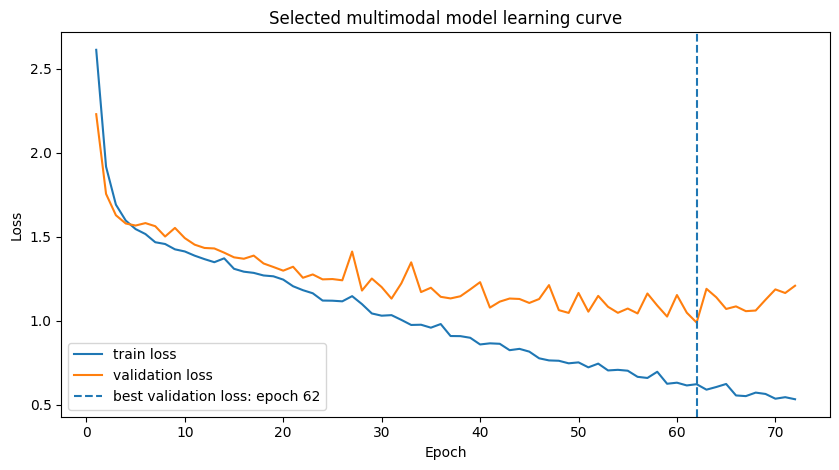

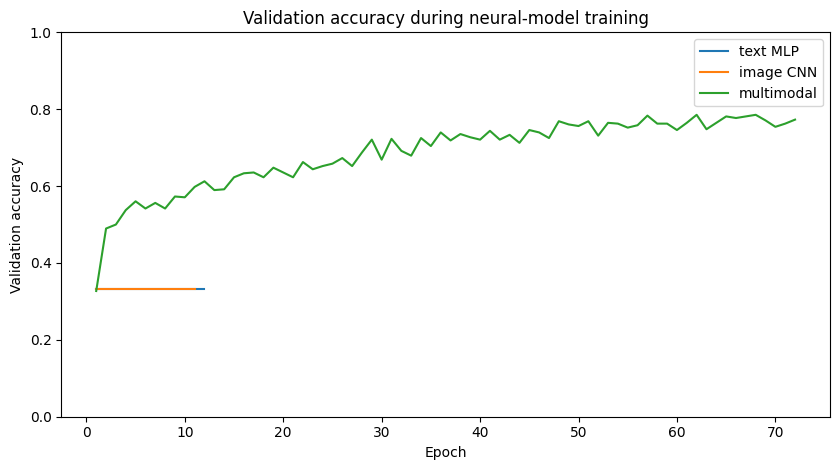

Best multimodal epoch by validation loss: 62
Recorded epochs before early stopping: 72


In [4]:
best_epoch = int(multimodal_history.loc[multimodal_history["val_loss"].idxmin(), "epoch"])

plt.figure(figsize=(8.5, 4.8))
plt.plot(multimodal_history["epoch"], multimodal_history["loss"], label="train loss")
plt.plot(multimodal_history["epoch"], multimodal_history["val_loss"], label="validation loss")
plt.axvline(best_epoch, linestyle="--", label=f"best validation loss: epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Selected multimodal model learning curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.5, 4.8))
plt.plot(text_history["epoch"], text_history["val_accuracy"], label="text MLP")
plt.plot(image_history["epoch"], image_history["val_accuracy"], label="image CNN")
plt.plot(multimodal_history["epoch"], multimodal_history["val_accuracy"], label="multimodal")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.ylim(0, 1)
plt.title("Validation accuracy during neural-model training")
plt.legend()
plt.tight_layout()
plt.show()

print("Best multimodal epoch by validation loss:", best_epoch)
print("Recorded epochs before early stopping:", len(multimodal_history))

## 4. Validation comparison

I compare all models on validation. The final test is not used to choose the model. The single-input models are sanity checks: each image and each text template is balanced across the three relation labels, so one side alone cannot determine the relation.

,model,modality,validation_accuracy,validation_macro_f1,correct_predictions,total_predictions
0,PyTorch multimodal CNN (Dataset V3),image + text,0.785417,0.787284,377,480
1,PyTorch neural text model,text,0.333333,0.292270,160,480
2,PyTorch CNN image model,image,0.333333,0.266627,160,480
3,Image + text Logistic Regression,image + text,0.333333,0.166667,160,480
4,Image pixels + Logistic Regression,image,0.333333,0.166667,160,480
5,Majority baseline,none,0.333333,0.166667,160,480
6,TF-IDF + Logistic Regression,text,0.333333,0.166667,160,480


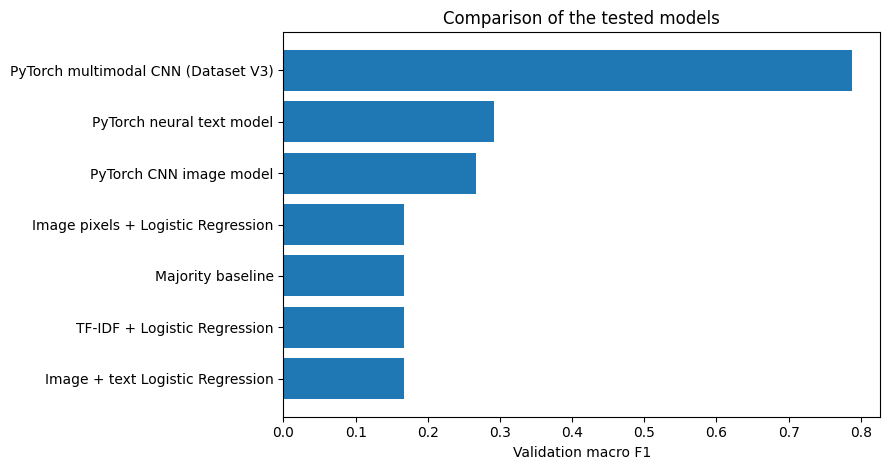

In [5]:
display(validation_comparison[[
    "model", "modality", "validation_accuracy", "validation_macro_f1",
    "correct_predictions", "total_predictions"
]])

plot_data = validation_comparison.sort_values("validation_macro_f1")
plt.figure(figsize=(9, 4.8))
plt.barh(plot_data["model"], plot_data["validation_macro_f1"])
plt.xlabel("Validation macro F1")
plt.title("Comparison of the tested models")
plt.tight_layout()
plt.show()

In [6]:
val_accuracy = accuracy_score(validation_predictions["true_label"], validation_predictions["predicted_label"])
val_macro_f1 = f1_score(
    validation_predictions["true_label"],
    validation_predictions["predicted_label"],
    average="macro",
    zero_division=0,
)
print(f"Selected validation result: {int(validation_predictions['is_correct'].sum())}/480")
print(f"Accuracy: {val_accuracy:.7f}")
print(f"Macro F1: {val_macro_f1:.7f}")

Selected validation result: 377/480
Accuracy: 0.7854167
Macro F1: 0.7872843


The multimodal model achieved **377/480** correct predictions, validation accuracy **0.7854**, and macro F1 **0.7873**. It was selected for the final evaluation.

The image-only and text-only results near one third are expected from the dataset construction and should not be read as a general claim that those architectures cannot classify images or text.

### Validation-only category-rule diagnostic

The relation label is defined from the image category and text category. I therefore compare the learned relation head with the result obtained by applying the same rule to the selected model's two helper category predictions. This is a decomposition of the selected model, not an independent baseline. The oracle row uses true categories only to verify the dataset construction.

In [7]:
diagnostic_table = pd.DataFrame([
    {
        "method": "learned relation head",
        "accuracy": category_rule_metrics["learned_relation_head"]["accuracy"],
        "macro_f1": category_rule_metrics["learned_relation_head"]["macro_f1"],
    },
    {
        "method": "rule on predicted categories",
        "accuracy": category_rule_metrics["predicted_category_rule"]["accuracy"],
        "macro_f1": category_rule_metrics["predicted_category_rule"]["macro_f1"],
    },
    {
        "method": "rule on true categories (construction check)",
        "accuracy": category_rule_metrics["oracle_category_rule"]["accuracy"],
        "macro_f1": category_rule_metrics["oracle_category_rule"]["macro_f1"],
    },
])
display(diagnostic_table)

print(
    "Image-category helper accuracy:",
    category_rule_metrics["auxiliary_category_predictions"]["image_category_accuracy"],
)
print(
    "Text-category helper accuracy:",
    category_rule_metrics["auxiliary_category_predictions"]["text_category_accuracy"],
)
print(
    "Learned-head accuracy gain over predicted-category rule:",
    category_rule_metrics["learned_head_minus_predicted_rule"]["accuracy"],
)
print("Final test used for this diagnostic:", category_rule_metrics["test_split_used"])

,method,accuracy,macro_f1
0,learned relation head,0.785417,0.787284
1,rule on predicted categories,0.729167,0.732404
2,rule on true categories (construction check),1.000000,1.000000


Image-category helper accuracy: 0.6625
Text-category helper accuracy: 1.0
Learned-head accuracy gain over predicted-category rule: 0.05625000000000002
Final test used for this diagnostic: False


The rule applied to predicted categories reaches accuracy **0.7292** and macro F1 **0.7324**. The learned relation head reaches **0.7854** and **0.7873**, about 0.0563 accuracy and 0.0549 macro F1 higher.

The text category is easy in this controlled dataset because it is explicitly named. The image category is harder at 0.6625 accuracy. The perfect oracle result is expected by construction and is not a deployable result.

## 5. Small additional experiment

This part is not required by the exam. I use it only to understand the selected model better.

I trained the same relation model without the two helper category outputs. I used seeds `43`, `44`, and `45`, and I used only train and validation data.

,run,trainable_parameters,correct_predictions,total_predictions,validation_accuracy,validation_macro_f1,predicted_class_distribution
0,selected model,58579,377,480,0.785417,0.787284,saved canonical predictions
1,"without helper tasks, seed 43",57923,160,480,0.333333,0.166667,"{""MATCH"": 480, ""MISMATCH"": 0, ""PARTIAL_MATCH"": 0}"
2,"without helper tasks, seed 44",57923,160,480,0.333333,0.166667,"{""MATCH"": 0, ""MISMATCH"": 480, ""PARTIAL_MATCH"": 0}"
3,"without helper tasks, seed 45",57923,160,480,0.333333,0.166667,"{""MATCH"": 0, ""MISMATCH"": 480, ""PARTIAL_MATCH"": 0}"


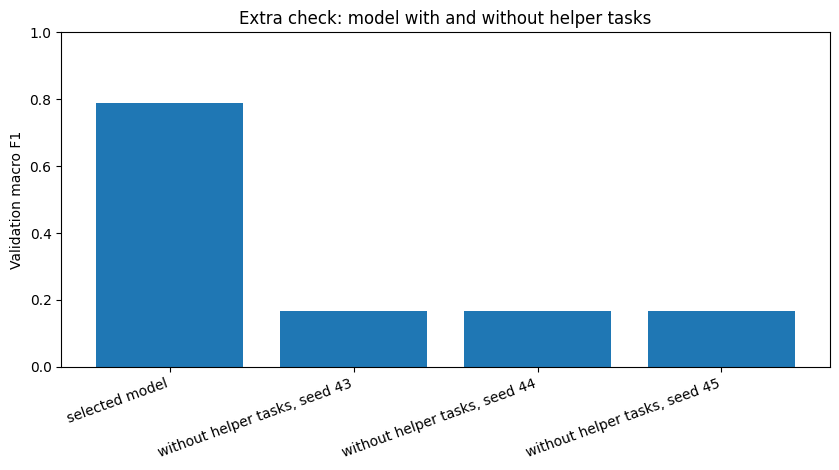

In [8]:
ablation_view = ablation_comparison.copy()
ablation_view["run"] = [
    "selected model" if row.experiment == "selected_multimodal_model"
    else f"without helper tasks, seed {int(row.seed)}"
    for row in ablation_view.itertuples()
]
display(ablation_view[[
    "run", "trainable_parameters", "correct_predictions", "total_predictions",
    "validation_accuracy", "validation_macro_f1", "predicted_class_distribution"
]])

plt.figure(figsize=(8.5, 4.8))
plt.bar(ablation_view["run"], ablation_view["validation_macro_f1"])
plt.ylim(0, 1)
plt.ylabel("Validation macro F1")
plt.title("Extra check: model with and without helper tasks")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [9]:
print("Seeds:", ablation_summary["no_auxiliary_aggregate"]["seeds"])
print("Mean accuracy without helper tasks:", ablation_summary["no_auxiliary_aggregate"]["mean_validation_accuracy"])
print("Mean macro F1 without helper tasks:", ablation_summary["no_auxiliary_aggregate"]["mean_validation_macro_f1"])
print("Predicted class by seed:", ablation_summary["no_auxiliary_aggregate"]["predicted_class_by_seed"])
print("Final test used in this experiment:", ablation_summary["test_split_used"])

Seeds: [43, 44, 45]
Mean accuracy without helper tasks: 0.3333333333333333
Mean macro F1 without helper tasks: 0.16666666666666666
Predicted class by seed: {'43': 'MATCH', '44': 'MISMATCH', '45': 'MISMATCH'}
Final test used in this experiment: False


All three runs without the helper tasks produced **160/480** correct predictions, accuracy **0.3333**, and macro F1 **0.1667**. Each run predicted only one class.

For this small architecture and dataset, the helper tasks stabilized optimization. This conclusion is limited to this experiment; it does not prove that auxiliary losses are always necessary.

## 6. Final-test result

After choosing the multimodal model from validation, the final test was used once. The cells below read the saved predictions and metrics. They do not run the model again.

In [10]:
test_accuracy = accuracy_score(test_predictions["true_label"], test_predictions["predicted_label"])
test_macro_f1 = f1_score(
    test_predictions["true_label"],
    test_predictions["predicted_label"],
    average="macro",
    zero_division=0,
)
print(f"Final-test result: {int(test_predictions['is_correct'].sum())}/480")
print(f"Accuracy: {test_accuracy:.7f}")
print(f"Macro F1: {test_macro_f1:.10f}")
print("This cell uses saved predictions; new inference performed: False")

Final-test result: 354/480
Accuracy: 0.7375000
Macro F1: 0.7382299830
This cell uses saved predictions; new inference performed: False


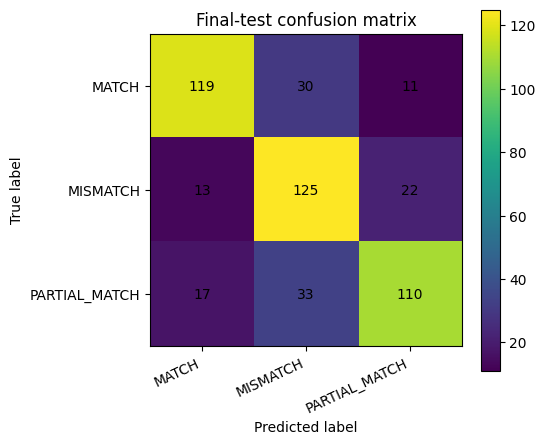

In [11]:
matrix = confusion_matrix(
    test_predictions["true_label"],
    test_predictions["predicted_label"],
    labels=["MATCH", "MISMATCH", "PARTIAL_MATCH"],
)
fig, ax = plt.subplots(figsize=(5.6, 4.8))
image = ax.imshow(matrix)
ax.set_xticks(range(3), ["MATCH", "MISMATCH", "PARTIAL_MATCH"], rotation=25, ha="right")
ax.set_yticks(range(3), ["MATCH", "MISMATCH", "PARTIAL_MATCH"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Final-test confusion matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(matrix[i, j]), ha="center", va="center")
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

The selected model achieved **354/480**, accuracy **0.7375**, and macro F1 **0.7382**. `PARTIAL_MATCH` is the hardest class: 110/160 examples are correct, and 33 are confused with `MISMATCH`.

## 7. Category results and concrete mistakes

,part_category,samples,independent_images,correct,accuracy,macro_f1
2,brake_pad,60,10,58,0.966667,0.966583
0,alternator,60,10,57,0.950000,0.950653
7,taillight,60,10,53,0.883333,0.884370
3,coil_spring,60,10,49,0.816667,0.820842
1,brake_disc,60,10,43,0.716667,0.716234
6,starter,60,10,35,0.583333,0.582694
5,oil_filter,60,10,30,0.500000,0.504202
4,headlight,60,10,29,0.483333,0.487733


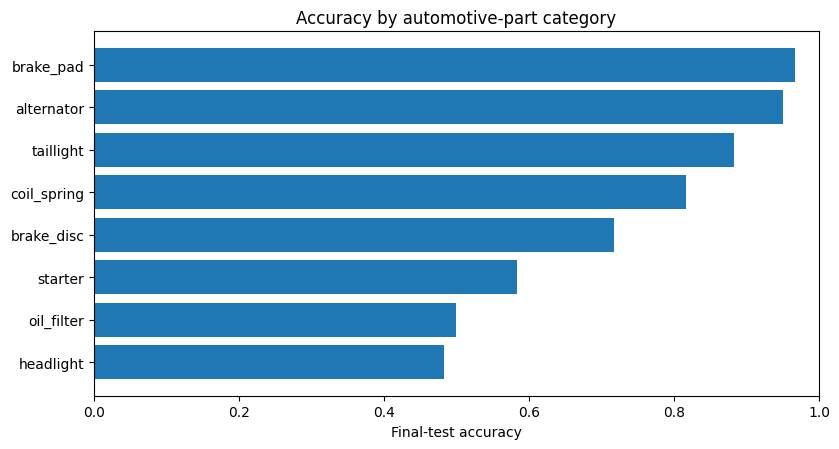

In [12]:
display(test_per_category.sort_values("accuracy", ascending=False))
plt.figure(figsize=(8.5, 4.6))
category_plot = test_per_category.sort_values("accuracy")
plt.barh(category_plot["part_category"], category_plot["accuracy"])
plt.xlim(0, 1)
plt.xlabel("Final-test accuracy")
plt.title("Accuracy by automotive-part category")
plt.tight_layout()
plt.show()

,part_category,text_category,description,true_label,predicted_label
67,brake_disc,brake_pad,"This vehicle part is a automotive brake pad, r...",PARTIAL_MATCH,MISMATCH
96,brake_disc,brake_disc,A brake disc or rotor from the vehicle chassis...,MATCH,MISMATCH
104,brake_disc,alternator,"This vehicle part is a automotive alternator, ...",MISMATCH,PARTIAL_MATCH
37,alternator,starter,A automotive starter motor from the engine-sup...,PARTIAL_MATCH,MATCH
212,coil_spring,oil_filter,"This vehicle part is a engine oil filter, reco...",MISMATCH,MATCH
156,brake_pad,brake_pad,A automotive brake pad from the vehicle chassi...,MATCH,PARTIAL_MATCH


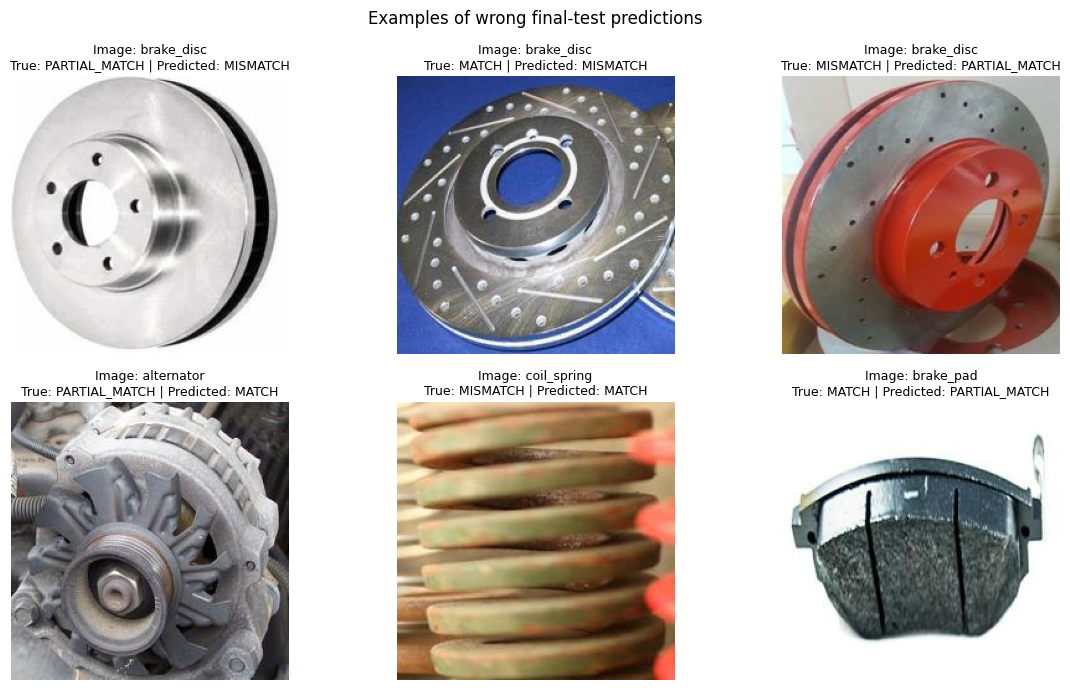

In [13]:
error_pairs = [
    ("PARTIAL_MATCH", "MISMATCH"),
    ("MATCH", "MISMATCH"),
    ("MISMATCH", "PARTIAL_MATCH"),
    ("PARTIAL_MATCH", "MATCH"),
    ("MISMATCH", "MATCH"),
    ("MATCH", "PARTIAL_MATCH"),
]

representative_errors = []
used_images = set()
for true_label, predicted_label in error_pairs:
    candidates = test_predictions[
        (test_predictions["true_label"] == true_label)
        & (test_predictions["predicted_label"] == predicted_label)
    ]
    for _, row in candidates.iterrows():
        if row["image_id"] not in used_images:
            representative_errors.append(row)
            used_images.add(row["image_id"])
            break

representative_errors = pd.DataFrame(representative_errors)
display(representative_errors[[
    "part_category", "text_category", "description", "true_label", "predicted_label"
]])

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (_, row) in zip(axes.flat, representative_errors.iterrows()):
    ax.imshow(plt.imread(PROJECT_ROOT / row["image_path"]))
    ax.set_title(
        f"Image: {row['part_category']}\n"
        f"True: {row['true_label']} | Predicted: {row['predicted_label']}",
        fontsize=9,
    )
    ax.axis("off")
plt.suptitle("Examples of wrong final-test predictions")
plt.tight_layout()
plt.show()

The weakest categories are `headlight` with **29/60** correct predictions and `oil_filter` with **30/60**.

The examples show two main problems:

- related parts can be confused, such as `brake_disc` with `brake_pad` and `alternator` with `starter`;
- some difficult images also cause wrong predictions even when the text describes the exact category.

This supports the idea that the model has learned useful relations, but it is still sensitive to image quality and visually or functionally similar parts.

## 8. Project checks

In [14]:
assert len(manifest) == 640
assert manifest["sha256"].nunique() == 640
assert int(validation_predictions["is_correct"].sum()) == 377
assert np.isclose(val_accuracy, 0.7854166666666667)
assert np.isclose(val_macro_f1, 0.787284319325806)
assert int(category_rule_diagnostic["category_rule_correct"].sum()) == 350
assert np.isclose(
    category_rule_metrics["predicted_category_rule"]["macro_f1"],
    0.7324044215433009,
)
assert category_rule_metrics["test_split_used"] is False
assert int(test_predictions["is_correct"].sum()) == 354
assert np.isclose(test_accuracy, 0.7375)
assert np.isclose(test_macro_f1, 0.7382299830250852)
assert ablation_summary["no_auxiliary_aggregate"]["seeds"] == [43, 44, 45]
assert ablation_summary["no_auxiliary_aggregate"]["all_runs_collapsed_to_one_predicted_class"] is True
assert ablation_summary["test_split_used"] is False
print("Notebook integrity checks: PASS")

Notebook integrity checks: PASS


For a complete check, run:

```powershell
python -m src.verify --full-hashes
python -m pytest -q
```

The normal evaluator works on validation only and reproduces both the saved relation predictions and the validation diagnostic. The final-test numbers in this notebook are recalculated from saved predictions; no final-test inference is performed.

## 9. Limitations

- The 3,840 rows are based on 640 independent images, so rows that share an image are not fully independent.
- The images come from one public dataset.
- Only eight categories are included, and the final test contains 80 images.
- The text is template-generated and explicitly names the category.
- The relation labels are created from category equality and manually defined functional families.
- The single-input checks are expected to remain near chance because the relation needs both inputs.
- The network is small, uses 48 × 48 images, and is trained from scratch.
- No pretrained vision backbone, resolution comparison, or visual attribution method is included.
- The additional experiment without helper tasks applies only to this model and training setup.
- The project is educational and is not ready for automatic warehouse decisions.

For real use, I would collect more images from different catalogues, warehouses, vehicle brands, and user-uploaded photos. I would also use freer text and keep a new external test set that was not used while developing the model.

## 10. Conclusion

The compact multimodal model learned the controlled image-text relation and reached validation macro F1 **0.7873** and final-test macro F1 **0.7382**. The main remaining difficulties are partial matches and the `headlight` and `oil_filter` categories.

The single-input checks confirm that one side alone cannot solve this balanced relation task. The validation-only category-rule diagnostic reaches macro F1 **0.7324**, while the learned relation head reaches **0.7873**, showing a useful gain beyond two hard category decisions.

The small additional experiment also showed that the helper category tasks stabilized training for this compact architecture. The result is useful as a student proof of concept, but the data and language are not varied enough for production decisions.

## 11. Sources

1. G. Piosenka, [50 Types of Car Parts - Image Classification](https://www.kaggle.com/datasets/gpiosenka/car-parts-40-classes), Kaggle dataset used as the image source.
2. T. Baltrušaitis, C. Ahuja, and L.-P. Morency, [Multimodal Machine Learning: A Survey and Taxonomy](https://arxiv.org/abs/1705.09406), 2017/2019.
3. Y. LeCun, L. Bottou, Y. Bengio, and P. Haffner, [Gradient-Based Learning Applied to Document Recognition](https://bottou.org/papers/lecun-98h), 1998.